In [58]:
import sys

import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
import torch
import torch.nn as nn

from src.utils import extract_ds_values, load_losses, ns_residuals, plot_field

sys.setrecursionlimit(10000)

In [59]:
H5_FILE = "../coarse_dataset/AllFields_Resultats_MESH_210.h5"
T = 8

RE = 520
nu = 1 / RE

Q = 7

P  = -3700 + 1.32 * Q

model = nn.Sequential(
    nn.Linear(2, 128), nn.Tanh(),
    nn.Linear(128, 128), nn.Tanh(),
    nn.Linear(128, 128), nn.Tanh(),
    nn.Linear(128, 128), nn.Tanh(),
    nn.Linear(128, 3)
).double()

model.load_state_dict(torch.load("../models/model_30/AN_model_01.pt"))
model.eval()

Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): Tanh()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): Tanh()
  (4): Linear(in_features=128, out_features=128, bias=True)
  (5): Tanh()
  (6): Linear(in_features=128, out_features=128, bias=True)
  (7): Tanh()
  (8): Linear(in_features=128, out_features=3, bias=True)
)

In [60]:
x, y, uv = extract_ds_values(H5_FILE, T)

inside_points = torch.tensor(
    np.column_stack((x / 20, y / 14)),
).double().requires_grad_(True)
inside_labels = torch.tensor(uv / 1000).double()

print(uv[:, 1].max() / 1000)

1.0710146484375


In [61]:
inside_results = model(inside_points)

x = inside_points.detach().numpy()[:, 0]
y = inside_points.detach().numpy()[:, 1]

u = inside_results.detach().numpy()[:, 0]
v = inside_results.detach().numpy()[:, 1]
p = inside_results.detach().numpy()[:, 2]

u_l = inside_labels.detach().numpy()[:, 0]
v_l = inside_labels.detach().numpy()[:, 1]

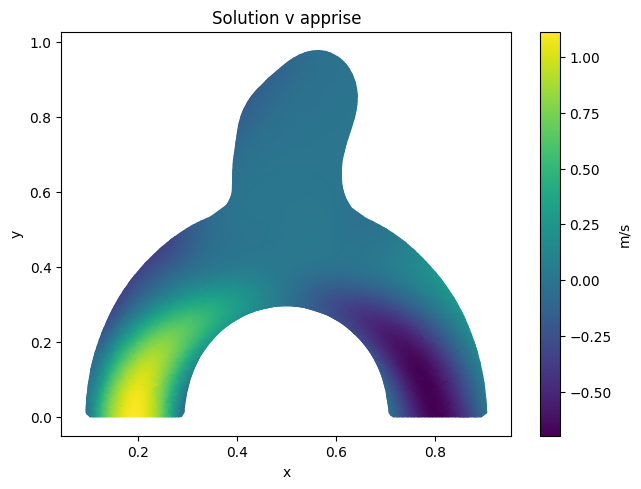

1.1123110580159055


In [77]:
plot_field(x, y, v, "Solution v apprise", "m/s", False)
print(v.max())

In [71]:
losses = load_losses("../models/model_30/AN_model_01.json")

Text(0.5, 1.0, "évolution de l'erreur liée aux données labélisées. err_finale = 1.027e-02")

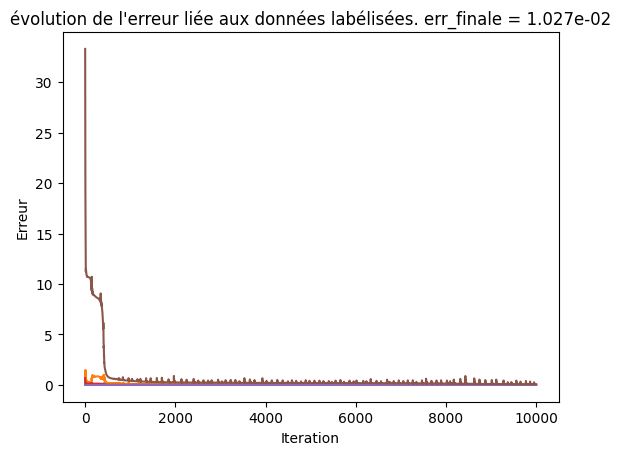

In [72]:
plt.plot(losses)
plt.ylabel("Erreur")
plt.xlabel("Iteration")
plt.title(f"évolution de l'erreur liée aux données labélisées. err_finale = {losses[:, 0][-1]:.3e}")

In [65]:
ns = ns_residuals(inside_points, inside_results[:, 0], inside_results[:, 1], inside_results[:, 2], nu)

ns_x = ns[0].detach().numpy()
ns_y = ns[1].detach().numpy()
cont = ns[2].detach().numpy()

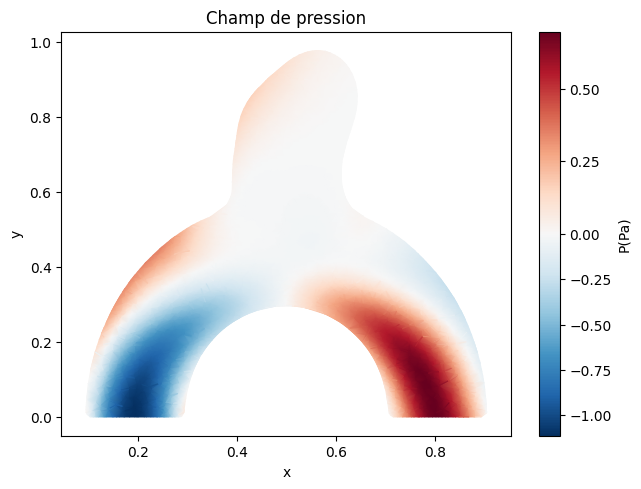

In [66]:
pressure = - inside_results.detach().numpy()[:, 1]# votre champ scalaire

plot_field(x, y, pressure, "Champ de pression", "P(Pa)")

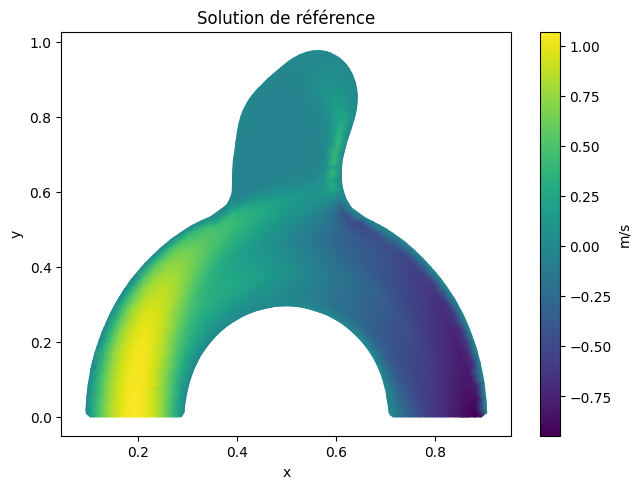

1.071014642715454


In [67]:
plot_field(x, y, v_l, "Solution de référence", "m/s", False)
print(v_l.max())

0.09716895868285953


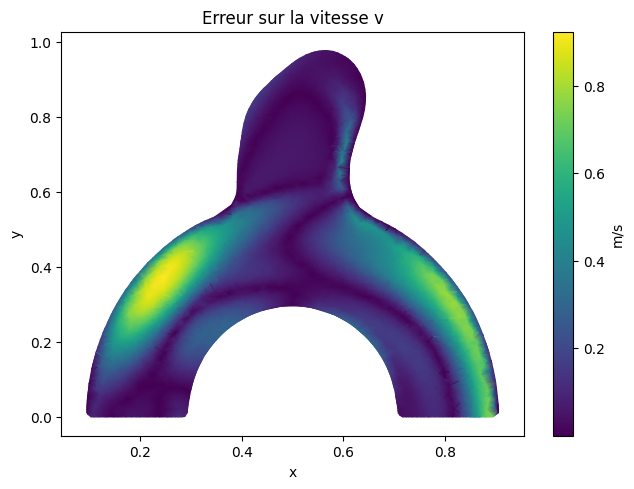

In [68]:
mse = nn.MSELoss()
print(mse(inside_labels[:, 1], inside_results[:, 1]).detach().numpy())
plot_field(x, y, np.abs(v_l - v), "Erreur sur la vitesse v", "m/s", False)

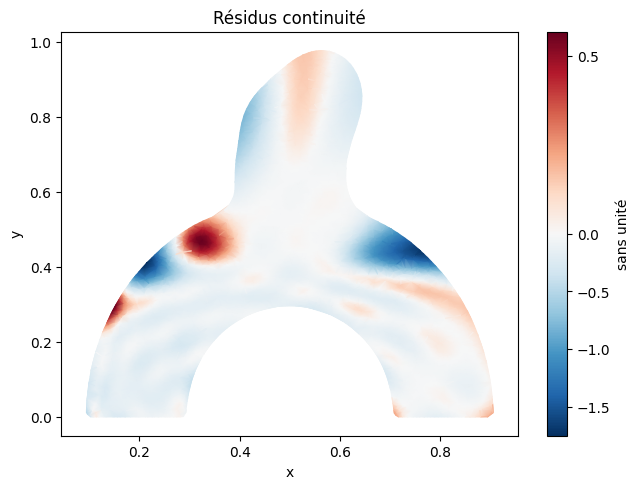

In [69]:
plot_field(x, y, cont, "Résidus continuité", "sans unité")

In [70]:
print(np.max(v))

1.1123110580159055
